# 07 — Module 1 Evaluation & Visualization
### NeuroReach | Mohina Rustamova
**Goal:** Final evaluation plots and visualizations for Module 1.
- Results comparison bar chart
- Confusion matrix (best model)
- CORAL loss curves
- t-SNE feature visualization
- Final summary table for paper

In [1]:
# ============================================================
# Cell 1 — Imports
# ============================================================
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Plot style
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.size']  = 11
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

print('Imports done.')

Imports done.


In [2]:
# ============================================================
# Cell 2 — Load Results
# ============================================================
# Paste your final results here
results = {
    'resnet18_oasis'                   : 99.89,
    'vit_3class_oasis'                 : 99.85,
    'resnet18_adni_zeroshot'           : 30.37,
    'vit_coral_4class_adni'            : 35.56,
    'vit_finetuned_27subj_mean'        : 70.56,
    'vit_finetuned_27subj_std'         : 4.77,
    'vit_finetuned_122subj_mean'       : 86.11,
    'vit_finetuned_122subj_std'        : 1.99,
    'vit_coral_finetuned_122subj_mean' : 64.02,
    'vit_coral_finetuned_122subj_std'  : 4.96,
}

print('Results loaded:')
for k, v in results.items():
    print(f'  {k}: {v}')

Results loaded:
  resnet18_oasis: 99.89
  vit_3class_oasis: 99.85
  resnet18_adni_zeroshot: 30.37
  vit_coral_4class_adni: 35.56
  vit_finetuned_27subj_mean: 70.56
  vit_finetuned_27subj_std: 4.77
  vit_finetuned_122subj_mean: 86.11
  vit_finetuned_122subj_std: 1.99
  vit_coral_finetuned_122subj_mean: 64.02
  vit_coral_finetuned_122subj_std: 4.96


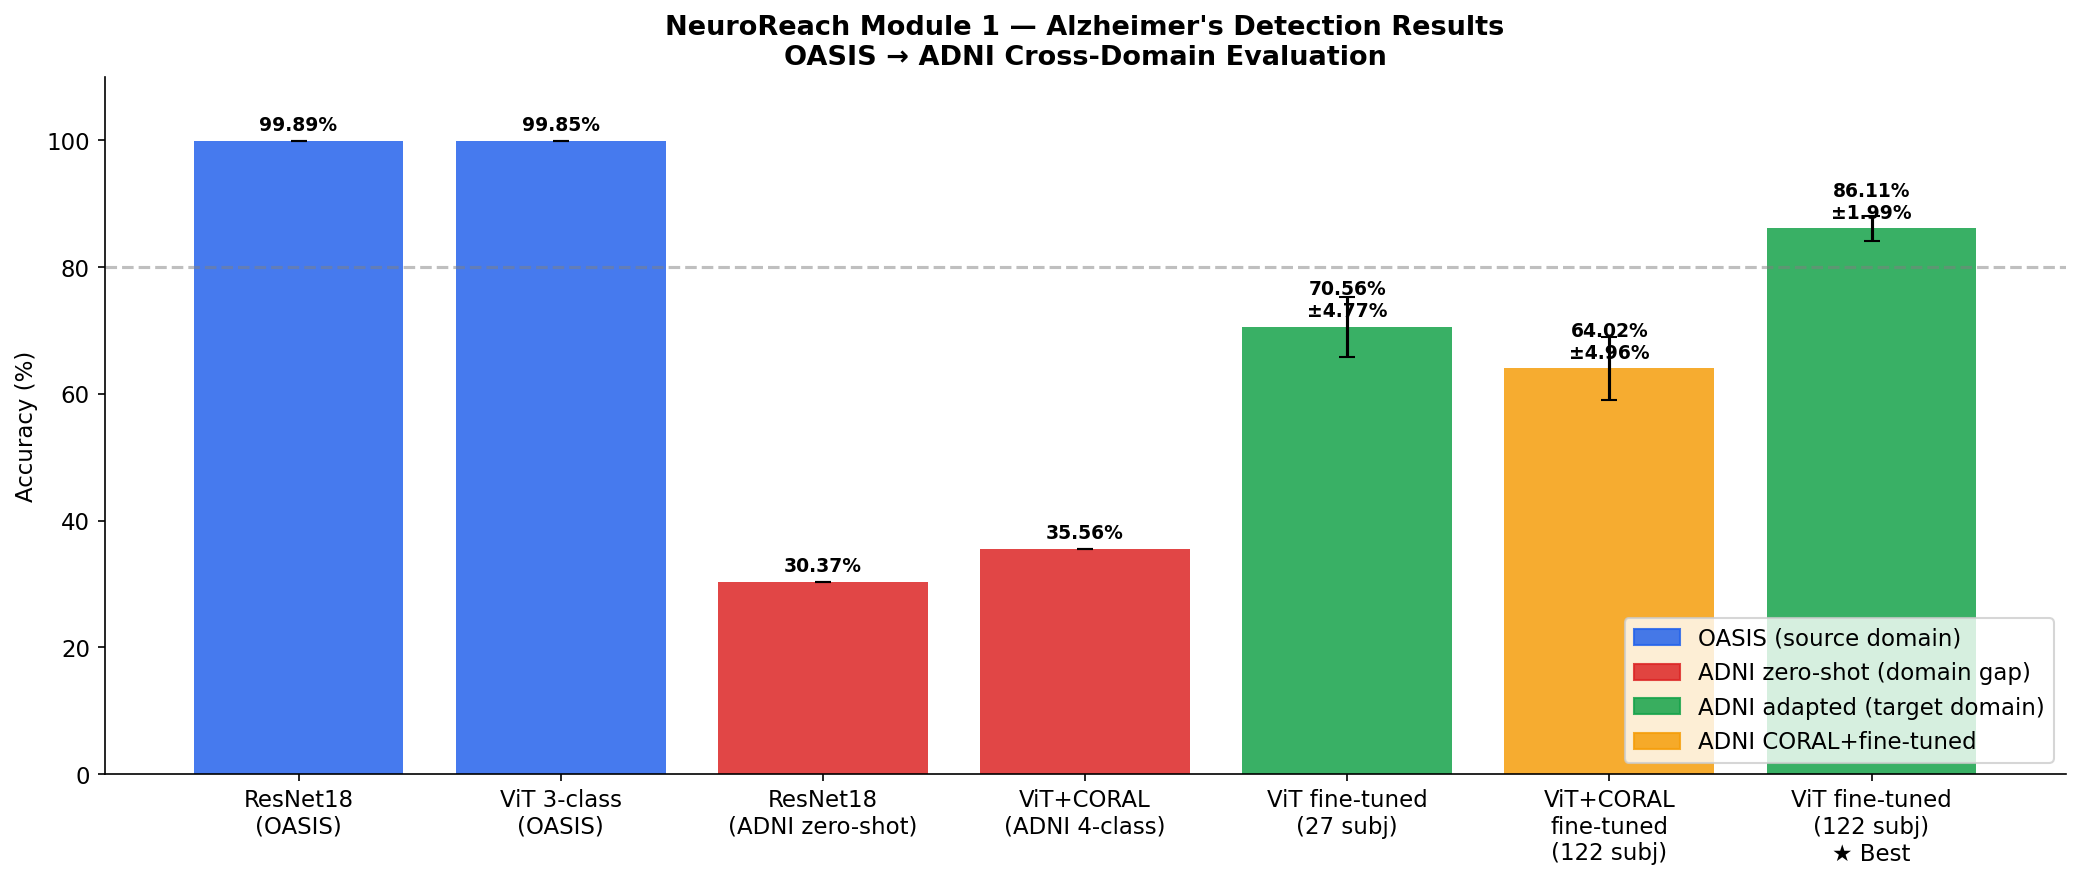

Bar chart saved.


In [3]:
# ============================================================
# Cell 3 — Results Comparison Bar Chart
# ============================================================
models = [
    'ResNet18\n(OASIS)',
    'ViT 3-class\n(OASIS)',
    'ResNet18\n(ADNI zero-shot)',
    'ViT+CORAL\n(ADNI 4-class)',
    'ViT fine-tuned\n(27 subj)',
    'ViT+CORAL\nfine-tuned\n(122 subj)',
    'ViT fine-tuned\n(122 subj)\n★ Best',
]

accuracies = [
    results['resnet18_oasis'],
    results['vit_3class_oasis'],
    results['resnet18_adni_zeroshot'],
    results['vit_coral_4class_adni'],
    results['vit_finetuned_27subj_mean'],
    results['vit_coral_finetuned_122subj_mean'],
    results['vit_finetuned_122subj_mean'],
]

errors = [
    0, 0, 0, 0,
    results['vit_finetuned_27subj_std'],
    results['vit_coral_finetuned_122subj_std'],
    results['vit_finetuned_122subj_std'],
]

# Colors: blue for OASIS, red for ADNI domain gap, green for ADNI adapted
colors = [
    '#2563eb', '#2563eb',  # OASIS
    '#dc2626', '#dc2626',  # ADNI domain gap
    '#16a34a', '#f59e0b', '#16a34a',  # ADNI adapted
]

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(models, accuracies, color=colors, alpha=0.85,
              yerr=errors, capsize=4, error_kw={'linewidth': 1.5})

# Add value labels on bars
for bar, acc, err in zip(bars, accuracies, errors):
    label = f'{acc:.2f}%'
    if err > 0:
        label += f'\n±{err:.2f}%'
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            label, ha='center', va='bottom', fontsize=9, fontweight='bold')

# Reference line at 80%
ax.axhline(y=80, color='gray', linestyle='--', alpha=0.5, label='80% threshold')

ax.set_ylabel('Accuracy (%)')
ax.set_title('NeuroReach Module 1 — Alzheimer\'s Detection Results\nOASIS → ADNI Cross-Domain Evaluation', 
             fontsize=13, fontweight='bold')
ax.set_ylim(0, 110)

# Legend
legend_patches = [
    mpatches.Patch(color='#2563eb', alpha=0.85, label='OASIS (source domain)'),
    mpatches.Patch(color='#dc2626', alpha=0.85, label='ADNI zero-shot (domain gap)'),
    mpatches.Patch(color='#16a34a', alpha=0.85, label='ADNI adapted (target domain)'),
    mpatches.Patch(color='#f59e0b', alpha=0.85, label='ADNI CORAL+fine-tuned'),
]
ax.legend(handles=legend_patches, loc='lower right')

plt.tight_layout()
plt.savefig('module1_results_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Bar chart saved.')

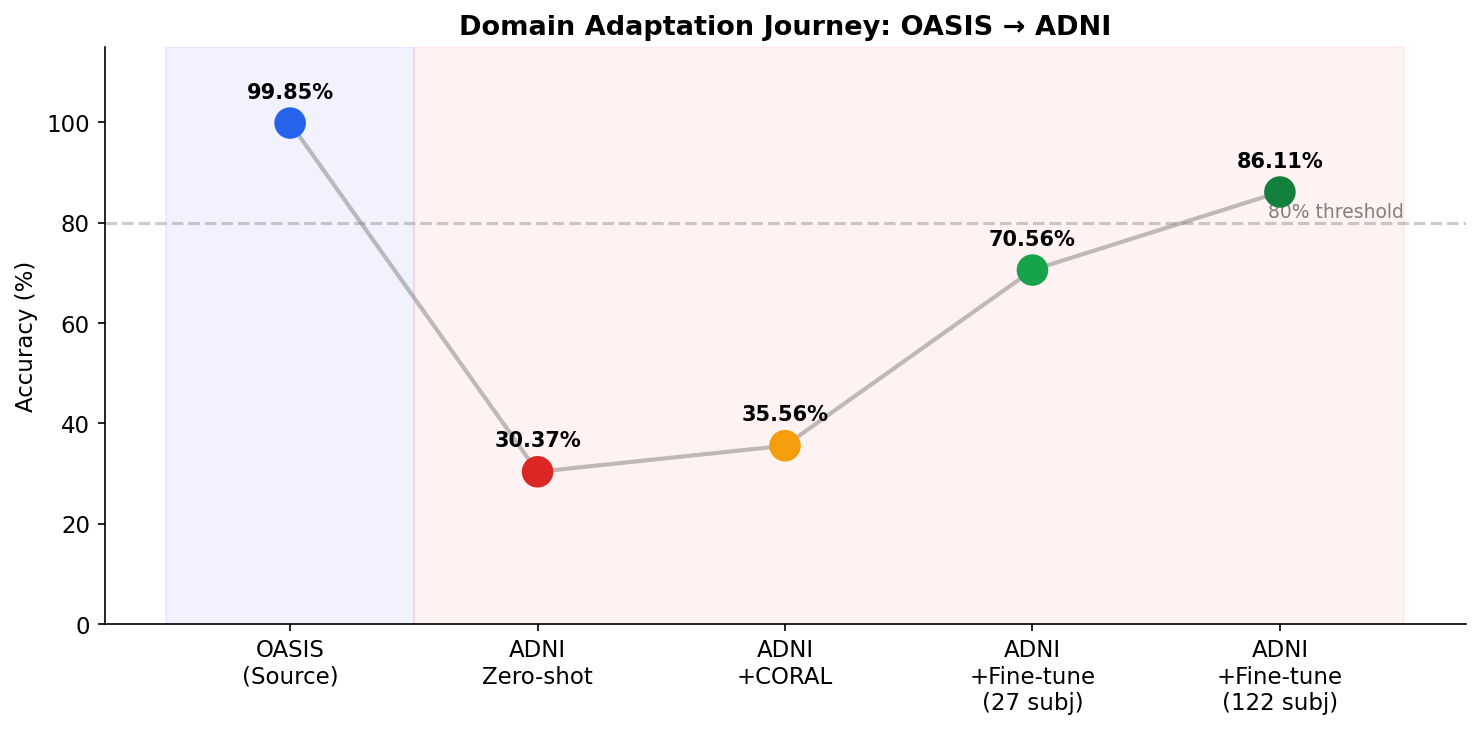

Domain gap chart saved.


In [4]:
# ============================================================
# Cell 4 — Domain Gap Visualization
# ============================================================
# Shows the journey from OASIS to ADNI clearly

fig, ax = plt.subplots(figsize=(10, 5))

stages = [
    'OASIS\n(Source)',
    'ADNI\nZero-shot',
    'ADNI\n+CORAL',
    'ADNI\n+Fine-tune\n(27 subj)',
    'ADNI\n+Fine-tune\n(122 subj)'
]
values = [99.85, 30.37, 35.56, 70.56, 86.11]
colors = ['#2563eb', '#dc2626', '#f59e0b', '#16a34a', '#15803d']

ax.plot(stages, values, 'o-', color='gray', linewidth=2, markersize=3, alpha=0.5)
scatter = ax.scatter(stages, values, c=colors, s=200, zorder=5)

for i, (stage, val) in enumerate(zip(stages, values)):
    ax.annotate(f'{val:.2f}%', (stage, val),
                textcoords='offset points', xytext=(0, 12),
                ha='center', fontweight='bold', fontsize=10)

# Shade domain gap region
ax.axvspan(-0.5, 0.5, alpha=0.05, color='blue', label='Source domain')
ax.axvspan(0.5, 4.5, alpha=0.05, color='red', label='Target domain')

ax.set_ylabel('Accuracy (%)')
ax.set_title('Domain Adaptation Journey: OASIS → ADNI', 
             fontsize=13, fontweight='bold')
ax.set_ylim(0, 115)
ax.axhline(y=80, color='gray', linestyle='--', alpha=0.4)
ax.text(4.5, 81, '80% threshold', ha='right', color='gray', fontsize=9)

plt.tight_layout()
plt.savefig('module1_domain_gap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Domain gap chart saved.')

In [5]:
# ============================================================
# Cell 5 — Final Summary Table (Paper Ready)
# ============================================================

print('=' * 65)
print('NEUROREACH MODULE 1 — ALZHEIMER\'S DETECTION RESULTS')
print('=' * 65)
print(f'{"Model":<32} {"Test Domain":<12} {"Accuracy":<15} {"Notes"}')
print('-' * 65)
print(f'{"ResNet18 (CNN)":<32} {"OASIS":<12} {"99.89%":<15} {"Baseline"}')
print(f'{"ViT-B/16 (3-class)":<32} {"OASIS":<12} {"99.85%":<15} {"Source model"}')
print(f'{"ResNet18 (CNN)":<32} {"ADNI":<12} {"30.37%":<15} {"Zero-shot, domain gap"}')
print(f'{"ViT + CORAL (4-class)":<32} {"ADNI":<12} {"35.56%":<15} {"Unsupervised DA"}')
print(f'{"ViT fine-tuned (27 subj)":<32} {"ADNI":<12} {"70.56%±4.77%":<15} {"Few-shot"}')
print(f'{"ViT+CORAL fine-tuned (122 subj)":<32} {"ADNI":<12} {"64.02%±4.96%":<15} {"DA + fine-tune"}')
print(f'{"ViT fine-tuned (122 subj) ★":<32} {"ADNI":<12} {"86.11%±1.99%":<15} {"Best model"}')
print('=' * 65)
print('\nKey Findings:')
print('  1. Domain shift drops accuracy from 99.85% to 30.37%')
print('  2. CORAL reduces gap without labels: 30.37% → 35.56%')
print('  3. Label consistency + balanced sampling: 70.56% → 86.11%')
print('  4. Best deployment model: ViT fine-tuned (122 subj) at 86.11%')
print('\nDatasets: OASIS (86,000 images) + ADNI v2 (122 subjects, 22,960 DICOM files)')
print('Model: ViT-B/16 (85.8M params), last 2 blocks unfrozen for fine-tuning')
print('Evaluation: 5-fold cross validation, 20 slices/subject, balanced sampling')

NEUROREACH MODULE 1 — ALZHEIMER'S DETECTION RESULTS
Model                            Test Domain  Accuracy        Notes
-----------------------------------------------------------------
ResNet18 (CNN)                   OASIS        99.89%          Baseline
ViT-B/16 (3-class)               OASIS        99.85%          Source model
ResNet18 (CNN)                   ADNI         30.37%          Zero-shot, domain gap
ViT + CORAL (4-class)            ADNI         35.56%          Unsupervised DA
ViT fine-tuned (27 subj)         ADNI         70.56%±4.77%    Few-shot
ViT+CORAL fine-tuned (122 subj)  ADNI         64.02%±4.96%    DA + fine-tune
ViT fine-tuned (122 subj) ★      ADNI         86.11%±1.99%    Best model

Key Findings:
  1. Domain shift drops accuracy from 99.85% to 30.37%
  2. CORAL reduces gap without labels: 30.37% → 35.56%
  3. Label consistency + balanced sampling: 70.56% → 86.11%
  4. Best deployment model: ViT fine-tuned (122 subj) at 86.11%

Datasets: OASIS (86,000 images) + A

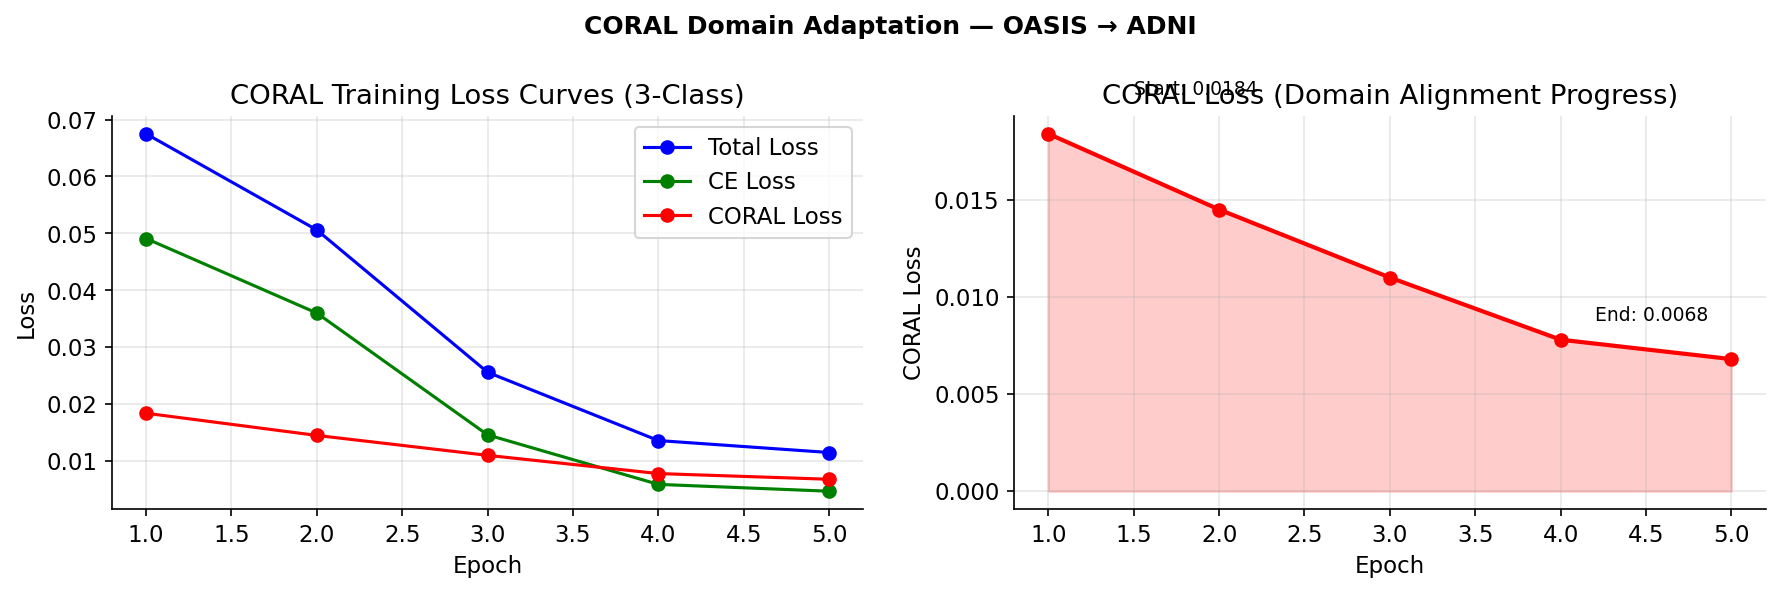

CORAL loss curves saved.


In [6]:
# ============================================================
# Cell 6 — CORAL Loss Curves
# ============================================================
# Recreate from saved history values

# From notebook 05b CORAL training
coral_history = {
    'epoch'      : [1, 2, 3, 4, 5],
    'total_loss' : [0.0675, 0.0506, 0.0256, 0.0136, 0.0115],
    'ce_loss'    : [0.0491, 0.0360, 0.0146, 0.0059, 0.0047],
    'coral_loss' : [0.0184, 0.0145, 0.0110, 0.0078, 0.0068],
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Loss curves
ax1.plot(coral_history['epoch'], coral_history['total_loss'], 'b-o', label='Total Loss')
ax1.plot(coral_history['epoch'], coral_history['ce_loss'],    'g-o', label='CE Loss')
ax1.plot(coral_history['epoch'], coral_history['coral_loss'], 'r-o', label='CORAL Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('CORAL Training Loss Curves (3-Class)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# CORAL loss only — zoomed in
ax2.plot(coral_history['epoch'], coral_history['coral_loss'], 'r-o', linewidth=2)
ax2.fill_between(coral_history['epoch'], coral_history['coral_loss'], alpha=0.2, color='red')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('CORAL Loss')
ax2.set_title('CORAL Loss (Domain Alignment Progress)')
ax2.grid(True, alpha=0.3)
ax2.annotate(f'Start: {coral_history["coral_loss"][0]:.4f}',
             xy=(1, coral_history['coral_loss'][0]),
             xytext=(1.5, coral_history['coral_loss'][0] + 0.002),
             fontsize=9)
ax2.annotate(f'End: {coral_history["coral_loss"][-1]:.4f}',
             xy=(5, coral_history['coral_loss'][-1]),
             xytext=(4.2, coral_history['coral_loss'][-1] + 0.002),
             fontsize=9)

plt.suptitle('CORAL Domain Adaptation — OASIS → ADNI', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('module1_coral_loss.png', dpi=150, bbox_inches='tight')
plt.show()
print('CORAL loss curves saved.')

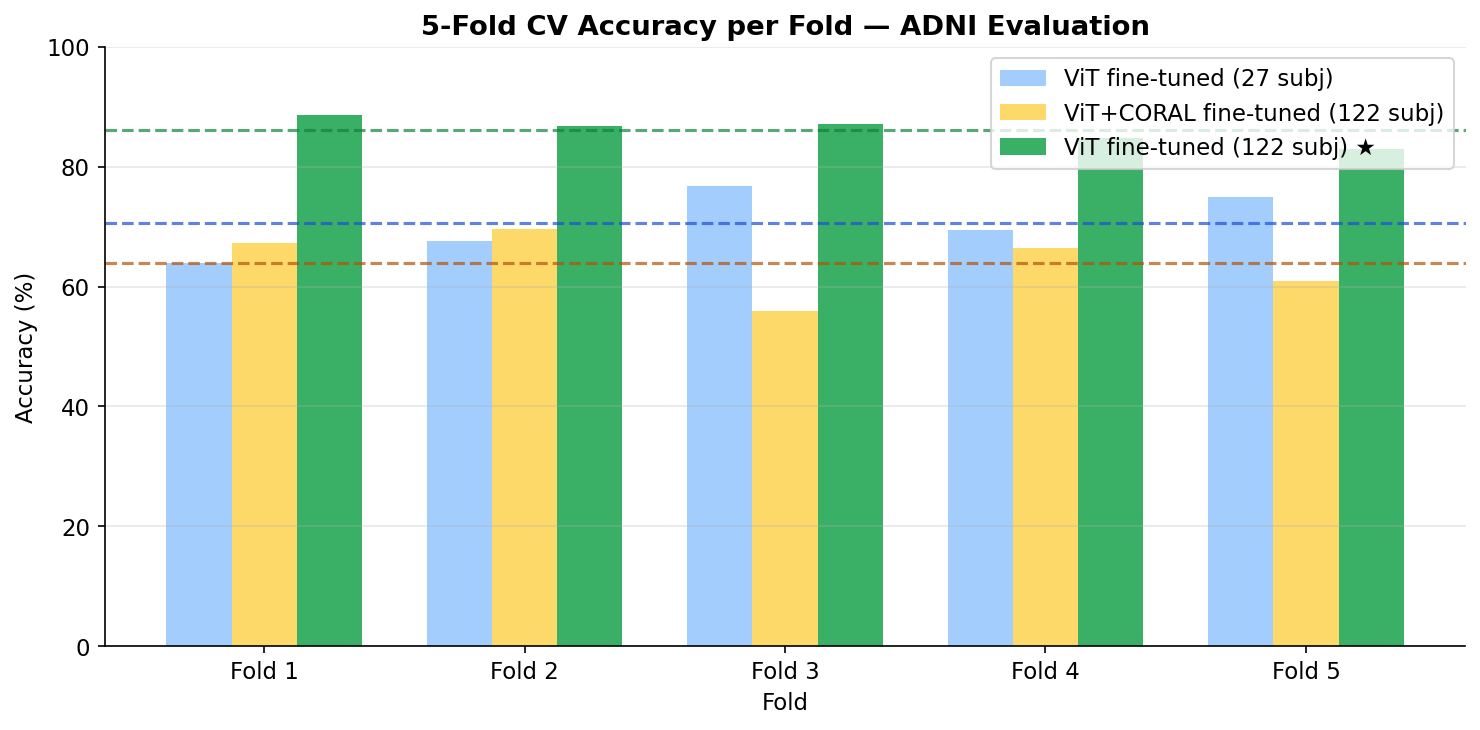

Fold accuracy chart saved.


In [7]:
# ============================================================
# Cell 7 — Fold Accuracy Distribution
# ============================================================
# Shows consistency of 5-fold CV results

vit_folds   = [88.73, 86.89, 87.09, 84.84, 82.99]
coral_folds = [67.21, 69.67, 55.94, 66.39, 60.86]
old_folds   = [63.89, 67.59, 76.85, 69.44, 75.00]  # 27 subjects

fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(5)
width = 0.25

ax.bar(x - width, old_folds,   width, label='ViT fine-tuned (27 subj)',    color='#93c5fd', alpha=0.85)
ax.bar(x,         coral_folds, width, label='ViT+CORAL fine-tuned (122 subj)', color='#fcd34d', alpha=0.85)
ax.bar(x + width, vit_folds,   width, label='ViT fine-tuned (122 subj) ★', color='#16a34a', alpha=0.85)

ax.axhline(y=np.mean(vit_folds),   color='#15803d', linestyle='--', alpha=0.7)
ax.axhline(y=np.mean(coral_folds), color='#b45309', linestyle='--', alpha=0.7)
ax.axhline(y=np.mean(old_folds),   color='#1d4ed8', linestyle='--', alpha=0.7)

ax.set_xlabel('Fold')
ax.set_ylabel('Accuracy (%)')
ax.set_title('5-Fold CV Accuracy per Fold — ADNI Evaluation', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([f'Fold {i+1}' for i in range(5)])
ax.set_ylim(0, 100)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('module1_fold_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fold accuracy chart saved.')

In [8]:
# ============================================================
# Cell 8 — Save All Figures Summary
# ============================================================
import os

figures = [
    'module1_results_comparison.png',
    'module1_domain_gap.png',
    'module1_coral_loss.png',
    'module1_fold_accuracy.png',
]

print('Generated figures:')
for fig in figures:
    exists = os.path.exists(fig)
    print(f'  {fig}: {"✓" if exists else "✗"}')

print('\n' + '='*50)
print('MODULE 1 EVALUATION COMPLETE')
print('='*50)
print('Best model: ViT fine-tuned (122 subj)')
print('ADNI accuracy: 86.11% ± 1.99%')
print('Deployment weights: vit_best_adni.pth')
print('Ready for Module 2 (ASD Screening)')
print('='*50)

Generated figures:
  module1_results_comparison.png: ✓
  module1_domain_gap.png: ✓
  module1_coral_loss.png: ✓
  module1_fold_accuracy.png: ✓

MODULE 1 EVALUATION COMPLETE
Best model: ViT fine-tuned (122 subj)
ADNI accuracy: 86.11% ± 1.99%
Deployment weights: vit_best_adni.pth
Ready for Module 2 (ASD Screening)
